# 07 - Are the Boltz-2 protein structures ordered? pLDDT across the library

Boltz-2 gives every residue a **pLDDT** (0-100, a confidence estimate: above 90 very high, 70-90 confident, 50-70 low, below 50 very low, which usually means a flexible or disordered stretch, or a region the model cannot place). Each ligand in the library is co-folded with the target, so the protein is predicted again for every compound; here the per-residue pLDDT is **sampled from about 400 random poses per target** (fewer for a target whose Pass-1 folding is still running), together with the confidence JSON of each pose. Secondary structure comes from PyMOL `dss` on the single reference structure used for the pose-density maps. Low pLDDT is a flag for uncertainty or disorder, not proof of it. Self-filling: targets without folded poses print `pending`.

In [1]:

import sys, warnings, shutil, subprocess
from pathlib import Path
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
warnings.filterwarnings("ignore")
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff"); sys.path.insert(0, str(ROOT / "pipeline_local"))
import bft_common as bc, bft_structure as bs
bc.style(); TARGETS = bc.TARGETS; SHORT = bc.SHORT
S, SS, DEN, MET = {}, {}, {}, {}
for t in TARGETS:
    try:
        s = bs.sample_poses(t)
        if s is None: print(f"pending: {SHORT[t]}: no folded poses / pose-density files yet"); continue
        S[t] = s; MET[t] = s["metrics"]; SS[t] = bs.dssp(t)
        DEN[t] = pd.read_csv(ROOT / "results/runs" / t / "pose_density/residue_density.csv")
        bs.write_plddt_pdb(t, s)
    except Exception as e: print(f"{SHORT[t]}: error {e!r}")
READY = list(S)
print("targets with data:", [SHORT[t] for t in READY], "| sampled poses per target:", {SHORT[t]: len(S[t]['plddt']) for t in READY})
MEAN = {t: S[t]["plddt"].mean(axis=0) * 100 for t in READY}          # per-residue pLDDT averaged over the sampled poses (0-100)
BAND = [(70, "#65cbf3"), (90, "#0053d6")]


targets with data: ['588689', '504329', '743445', '485317', '2097', '493091', '2650', '588549'] | sampled poses per target: {'588689': 400, '504329': 400, '743445': 400, '485317': 400, '2097': 404, '493091': 400, '2650': 408, '588549': 311}


## 1. Per-target summary
Residues, secondary-structure content of the reference structure, and the share of residues in each pLDDT band (per-residue pLDDT averaged over the sampled poses), plus the pose-level confidence summaries.

In [2]:
rows = []
for t in READY:
    m = MEAN[t]; d = SS[t] or ""; n = len(m); M = MET[t]
    rows.append({"target": SHORT[t], "residues": n, "poses sampled": len(M),
        "helix %": round(100 * d.count("H") / n, 0) if d else np.nan, "sheet %": round(100 * d.count("S") / n, 0) if d else np.nan,
        "mean pLDDT": round(m.mean(), 1), "% residues < 50": round(100 * (m < 50).mean(), 1), "% < 70": round(100 * (m < 70).mean(), 1), "% >= 90": round(100 * (m >= 90).mean(), 1),
        "complex pLDDT median": round(M.complex_plddt.median(), 3), "ptm median": round(M.ptm.median(), 3), "ligand ipTM median": round(M.ligand_iptm.median(), 3)})
T1 = pd.DataFrame(rows).set_index("target"); display(T1)

,residues,poses sampled,helix %,sheet %,mean pLDDT,% residues < 50,% < 70,% >= 90,complex pLDDT median,ptm median,ligand ipTM median
target,,,,,,,,,,,
588689,275,400,38.0,14.0,94.099998,0.7,5.8,89.5,0.921,0.949,0.863
504329,219,400,47.0,23.0,81.900002,10.0,19.2,41.1,0.788,0.832,0.876
743445,141,400,39.0,21.0,95.400002,0.0,0.7,90.1,0.948,0.964,0.944
485317,139,400,65.0,0.0,88.900002,0.0,16.5,69.8,0.875,0.866,0.928
2097,420,404,34.0,17.0,87.400002,9.8,15.5,71.0,0.869,0.912,0.934
493091,180,400,33.0,26.0,97.099998,0.0,0.0,97.2,0.940,0.974,0.914
2650,345,408,35.0,17.0,96.000000,0.0,0.9,92.2,0.950,0.977,0.904
588549,580,311,34.0,22.0,90.400002,0.3,6.4,69.5,0.894,0.915,0.904


## 2. pLDDT along the sequence, with secondary structure
One panel per target. Black line: mean per-residue pLDDT over the sampled poses; grey band: 5th-95th percentile across poses. The coloured strip under the curve is the secondary structure of the reference structure (dark = helix, mid-grey = sheet, white = loop). Dashed lines mark pLDDT 50 and 70.

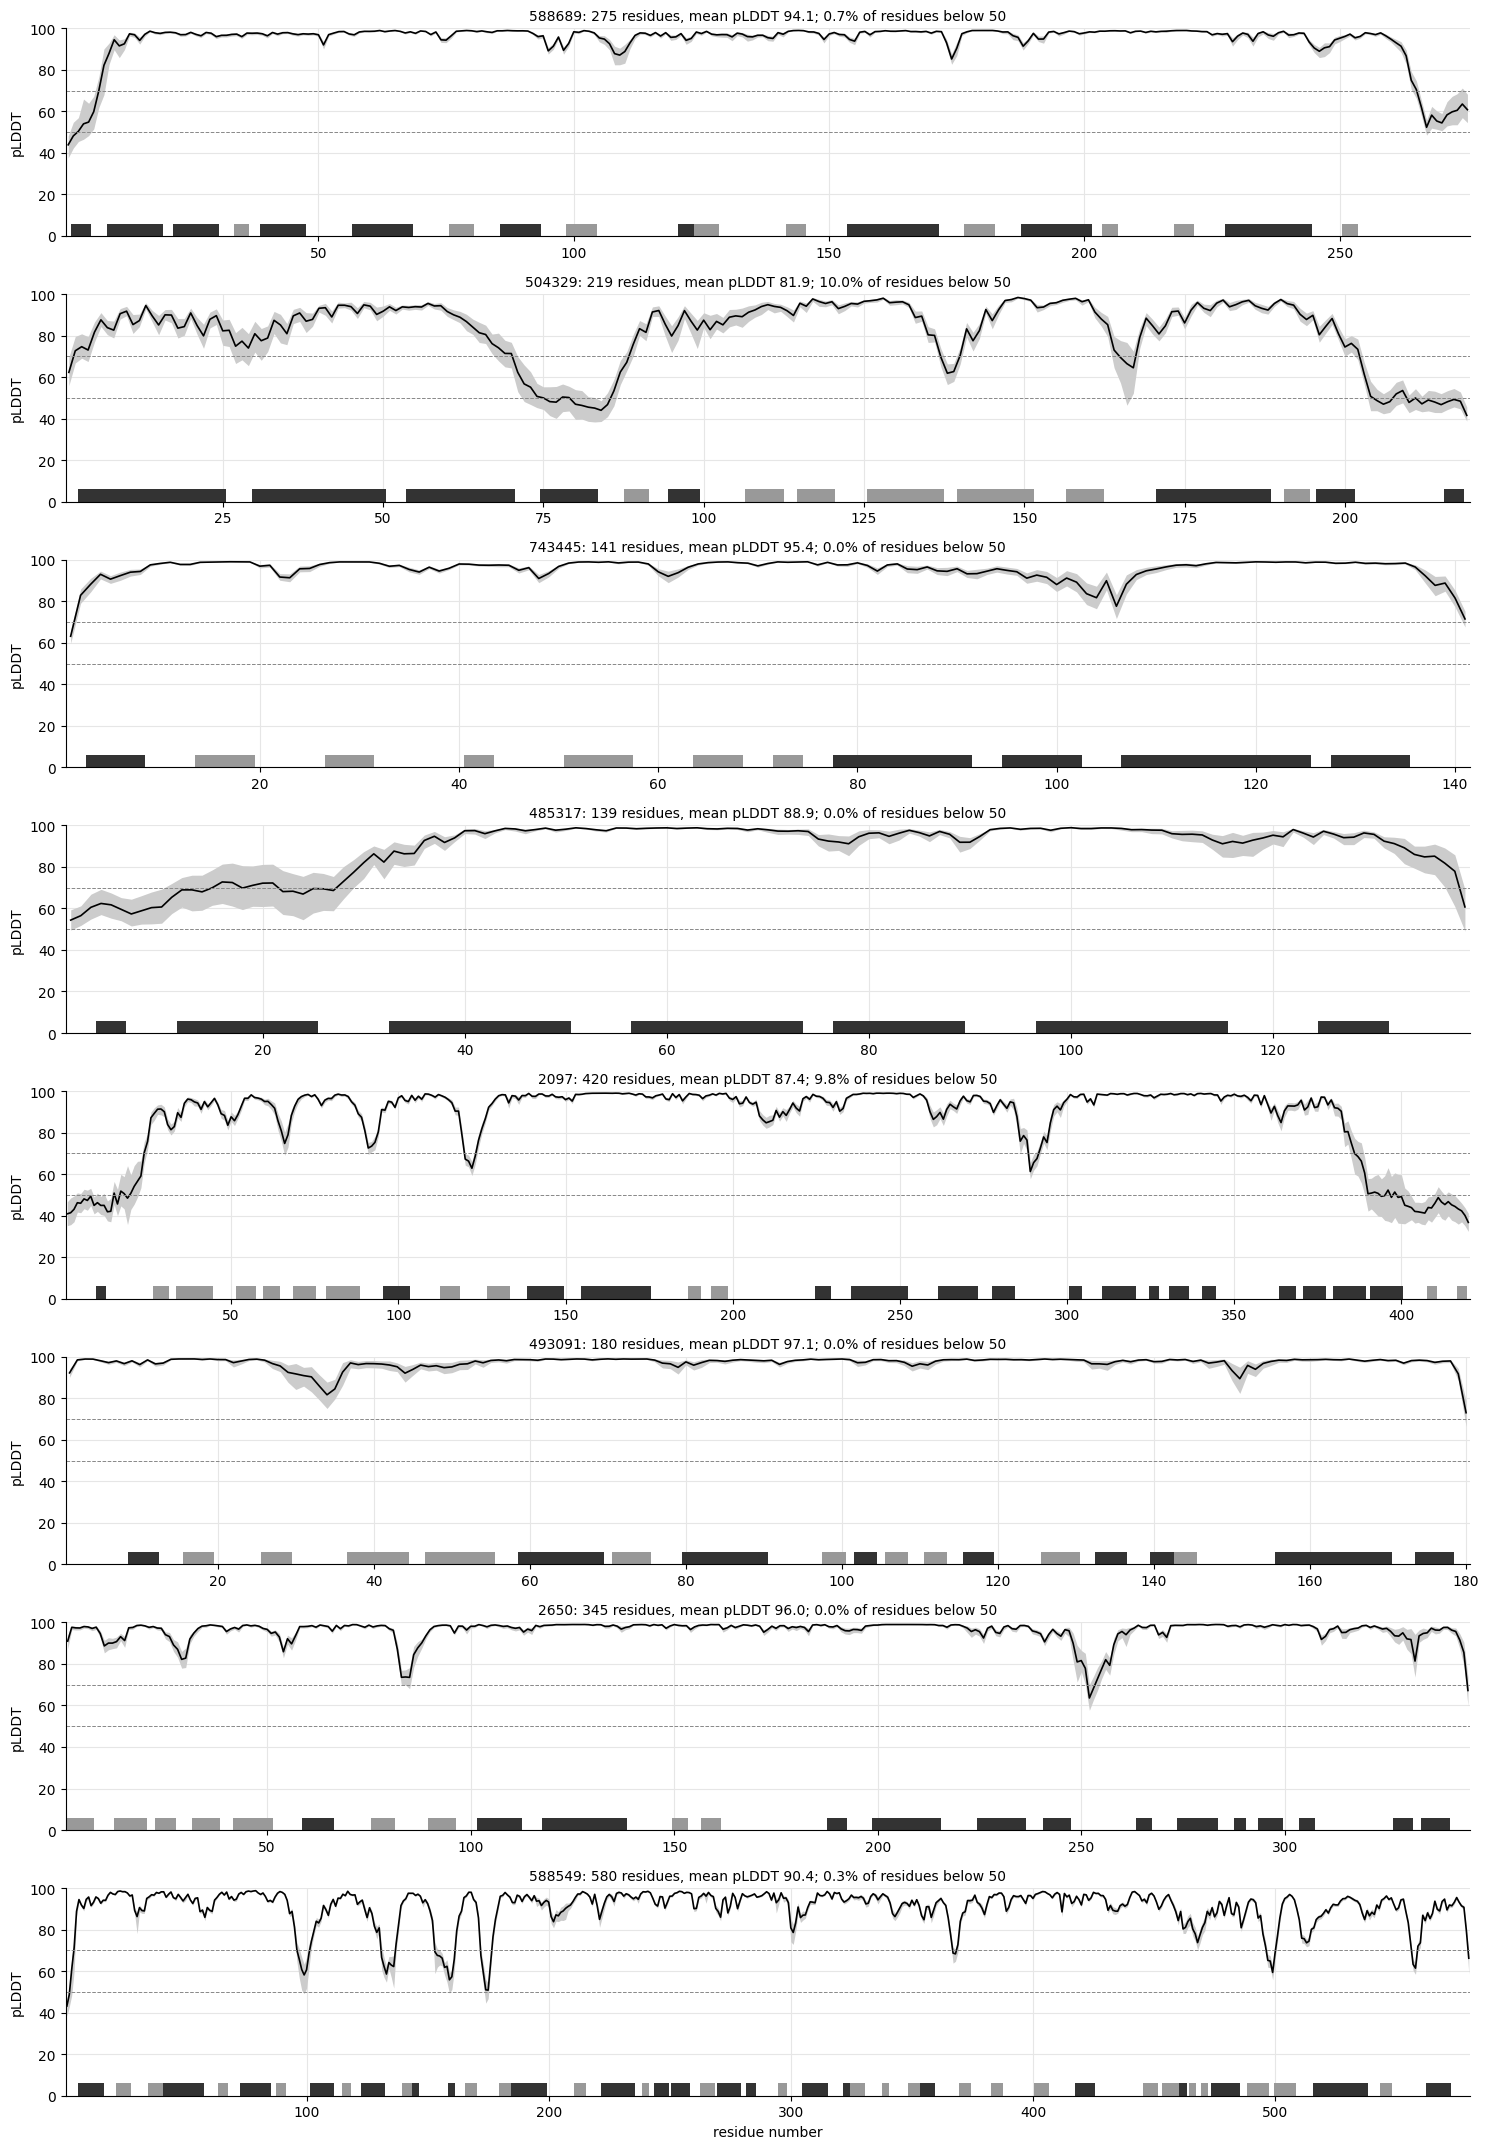

In [3]:
if READY:
    fig, axes = plt.subplots(len(READY), 1, figsize=(15, 2.7 * len(READY)))
    axes = np.atleast_1d(axes)
    for ax, t in zip(axes, READY):
        P = S[t]["plddt"] * 100; x = np.arange(1, P.shape[1] + 1); m = P.mean(0)
        ax.fill_between(x, np.percentile(P, 5, axis=0), np.percentile(P, 95, axis=0), color="#cccccc", lw=0); ax.plot(x, m, color="black", lw=1.2)
        for y in (50, 70): ax.axhline(y, ls="--", color="#888888", lw=0.7)
        d = SS[t]
        if d:
            for i, c in enumerate(d):
                if c in "HS": ax.add_patch(plt.Rectangle((i + 0.5, 0), 1, 6, color="#333333" if c == "H" else "#999999", lw=0))
        ax.set_ylim(0, 100); ax.set_xlim(0.5, len(m) + 0.5); ax.set_ylabel("pLDDT")
        ax.set_title(f"{SHORT[t]}: {len(m)} residues, mean pLDDT {m.mean():.1f}; {100 * (m < 50).mean():.1f}% of residues below 50", fontsize=10)
    axes[-1].set_xlabel("residue number")
    plt.tight_layout(); plt.show()

## 3. Distributions: per-residue pLDDT and pose-level confidence
Left: per-residue mean pLDDT (each residue one value). Right: the confidence JSON of each sampled pose (complex pLDDT, pTM, ligand ipTM); each box is one target.

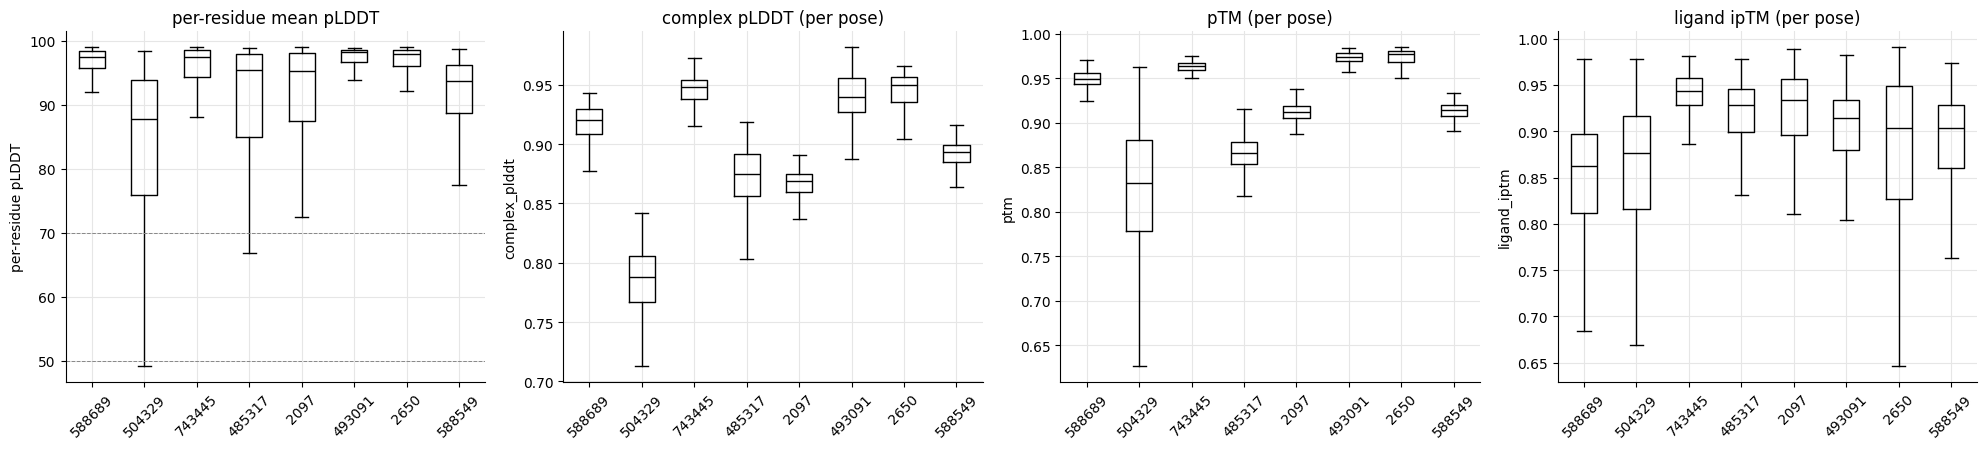

In [4]:
if READY:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
    axes[0].boxplot([MEAN[t] for t in READY], labels=[SHORT[t] for t in READY], showfliers=False, medianprops=dict(color="black"))
    axes[0].axhline(50, ls="--", color="#888888", lw=0.7); axes[0].axhline(70, ls="--", color="#888888", lw=0.7); axes[0].set_ylabel("per-residue pLDDT"); axes[0].set_title("per-residue mean pLDDT")
    for ax, col, ti in zip(axes[1:], ["complex_plddt", "ptm", "ligand_iptm"], ["complex pLDDT (per pose)", "pTM (per pose)", "ligand ipTM (per pose)"]):
        ax.boxplot([MET[t][col] for t in READY], labels=[SHORT[t] for t in READY], showfliers=False, medianprops=dict(color="black")); ax.set_title(ti); ax.set_ylabel(col)
    for ax in axes: ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

## 4. Is low pLDDT concentrated in loops and termini?
For each target, the share of residues with pLDDT below 70 within helices, sheets and loops (reference-structure secondary structure), and where the residues below 50 sit along the chain (first or last 10% of the sequence versus the middle).

,% < 70 in helix,% < 70 in sheet,% < 70 in loop,residues < 50,of which in first/last 10%
target,,,,,
588689,3.8,0.0,9.2,2,2
504329,11.8,4.0,41.8,22,13
743445,0.0,0.0,1.8,0,0
485317,13.2,NaN,22.9,0,0
2097,11.9,8.3,20.5,41,41
493091,0.0,0.0,0.0,0,0
2650,0.0,0.0,1.8,0,0
588549,2.5,1.6,11.9,2,2


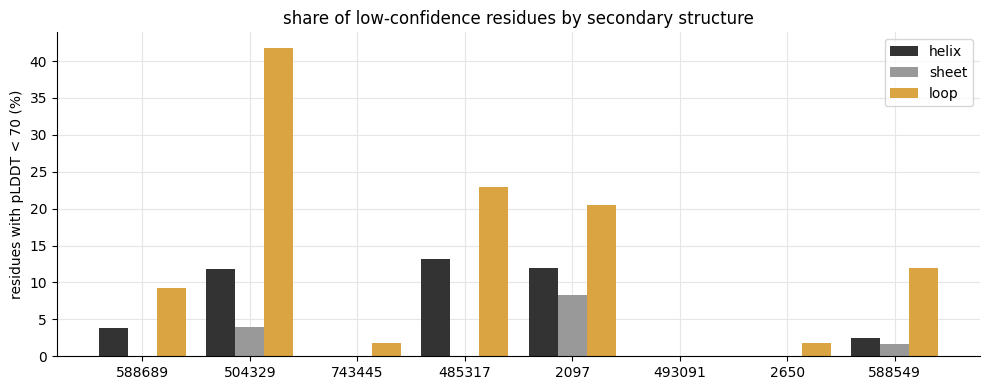

In [5]:
rows = []
for t in READY:
    m = MEAN[t]; d = SS[t]
    if not d: continue
    d = np.array(list(d)); n = len(m); idx = np.arange(n); term = (idx < 0.1 * n) | (idx >= 0.9 * n)
    r = {"target": SHORT[t]}
    for c, nm in (("H", "helix"), ("S", "sheet"), ("L", "loop")): r[f"% < 70 in {nm}"] = round(100 * (m[d == c] < 70).mean(), 1) if (d == c).any() else np.nan
    low = m < 50; r["residues < 50"] = int(low.sum()); r["of which in first/last 10%"] = int((low & term).sum())
    rows.append(r)
T4 = pd.DataFrame(rows).set_index("target"); display(T4)
if len(T4):
    fig, ax = plt.subplots(figsize=(10, 4)); x = np.arange(len(T4)); w = 0.27
    for k, (c, col) in enumerate([("% < 70 in helix", "#333333"), ("% < 70 in sheet", "#999999"), ("% < 70 in loop", "#d9a441")]):
        ax.bar(x + (k - 1) * w, T4[c], w, color=col, label=c.replace("% < 70 in ", ""))
    ax.set_xticks(x); ax.set_xticklabels(T4.index); ax.set_ylabel("residues with pLDDT < 70 (%)"); ax.set_title("share of low-confidence residues by secondary structure"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Do the library's poses sit on confidently predicted residues?
Per target, per residue: pose-contact frequency against mean pLDDT, with the Spearman correlation. A positive or null correlation means poses are not concentrated in low-confidence regions.

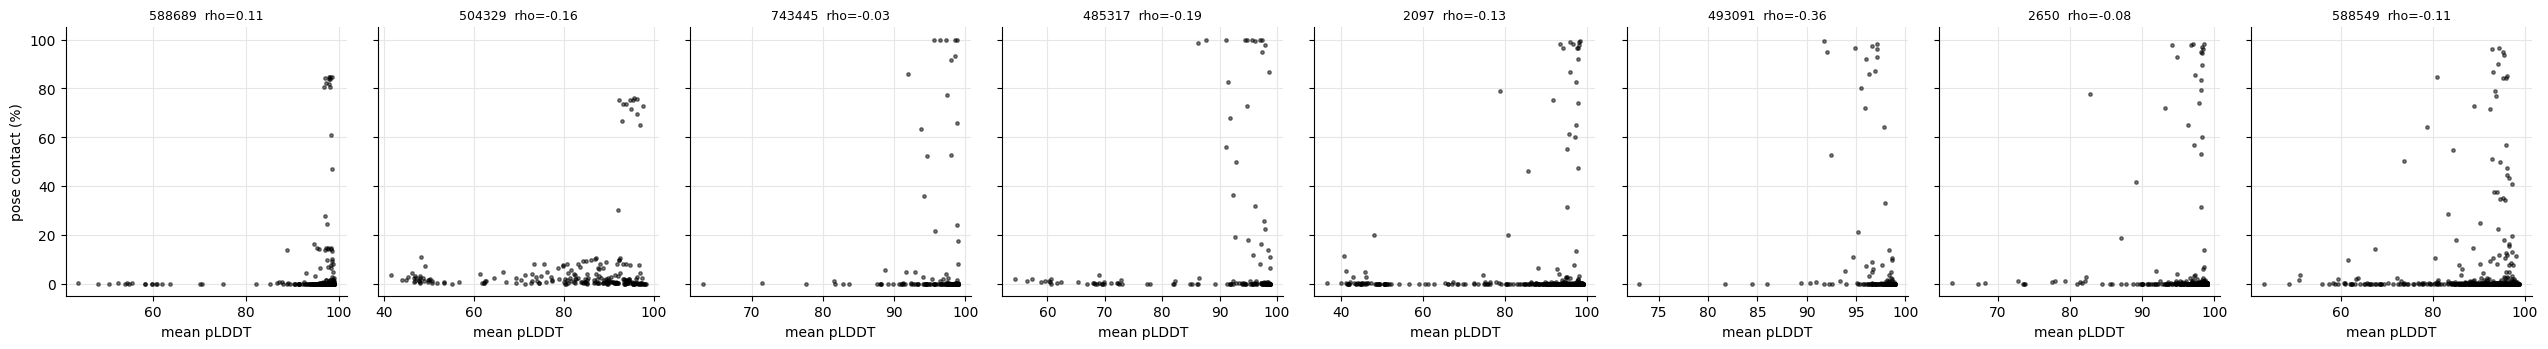

,Spearman rho,p
target,,
588689,0.113,6.100000e-02
504329,-0.159,1.900000e-02
743445,-0.028,7.400000e-01
485317,-0.192,2.400000e-02
2097,-0.133,6.500000e-03
493091,-0.357,8.800000e-07
2650,-0.082,1.300000e-01
588549,-0.109,8.700000e-03


In [6]:
if READY:
    n = len(READY); fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.6), sharey=True); axes = np.atleast_1d(axes); rows = []
    for ax, t in zip(axes, READY):
        x = MEAN[t]; y = DEN[t].contact_frac.values * 100; rho, p = stats.spearmanr(x, y)
        ax.scatter(x, y, s=6, color="black", alpha=0.5); ax.set_title(f"{SHORT[t]}  rho={rho:.2f}", fontsize=9); ax.set_xlabel("mean pLDDT"); rows.append({"target": SHORT[t], "Spearman rho": round(rho, 3), "p": float(f"{p:.2g}")})
    axes[0].set_ylabel("pose contact (%)"); plt.tight_layout(); plt.show(); display(pd.DataFrame(rows).set_index("target"))

### 5b. How localised are the poses?
Per target: the share of all pose contacts carried by the 10% most-contacted residues, the residues touched in at least half of the library's poses ("hot"), their pLDDT against the rest, and how many very-low-confidence residues (pLDDT below 50) are touched in at least 10% of poses. Contact frequency is the fraction of the library's poses whose ligand touches the residue (pose-density map of the reference structure).

In [7]:
rows = []
for t in READY:
    m = MEAN[t]; cf = DEN[t].contact_frac.values; n = len(cf); order = np.argsort(-cf); top10 = cf[order[:int(np.ceil(0.1 * n))]].sum() / cf.sum(); hot = cf >= 0.5; low = m < 50
    rows.append({"target": SHORT[t], "residues": n, "% of contacts on top 10% residues": round(100 * top10, 0), "hot residues (>= 50% of poses)": int(hot.sum()), "% of residues hot": round(100 * hot.mean(), 1),
                 "mean pLDDT hot": round(m[hot].mean(), 1) if hot.any() else np.nan, "mean pLDDT rest": round(m[~hot].mean(), 1), "residues pLDDT < 50": int(low.sum()), "...of which touched in >= 10% of poses": int((low & (cf >= 0.1)).sum())})
T5b = pd.DataFrame(rows).set_index("target"); display(T5b)

,residues,% of contacts on top 10% residues,hot residues (>= 50% of poses),% of residues hot,mean pLDDT hot,mean pLDDT rest,residues pLDDT < 50,...of which touched in >= 10% of poses
target,,,,,,,,
588689,275,94.0,11,4.0,97.800003,94.000000,2,0
504329,219,74.0,12,5.5,95.000000,81.099998,22,1
743445,141,93.0,13,9.2,96.800003,95.300003,0,0
485317,139,76.0,16,11.5,94.000000,88.199997,0,0
2097,420,99.0,19,4.5,95.599998,87.000000,41,2
493091,180,94.0,14,7.8,95.599998,97.300003,0,0
2650,345,98.0,20,5.8,96.500000,96.000000,0,0
588549,580,97.0,19,3.3,90.800003,90.400002,2,0


## 6. Is the protein fold the same across compounds?
Because the protein is re-predicted for every ligand, the per-residue pLDDT can change from compound to compound. Per target: the spread (SD over sampled poses) of the per-pose protein pLDDT, and the per-residue SD along the sequence (large SD marks regions whose confidence depends on the ligand).

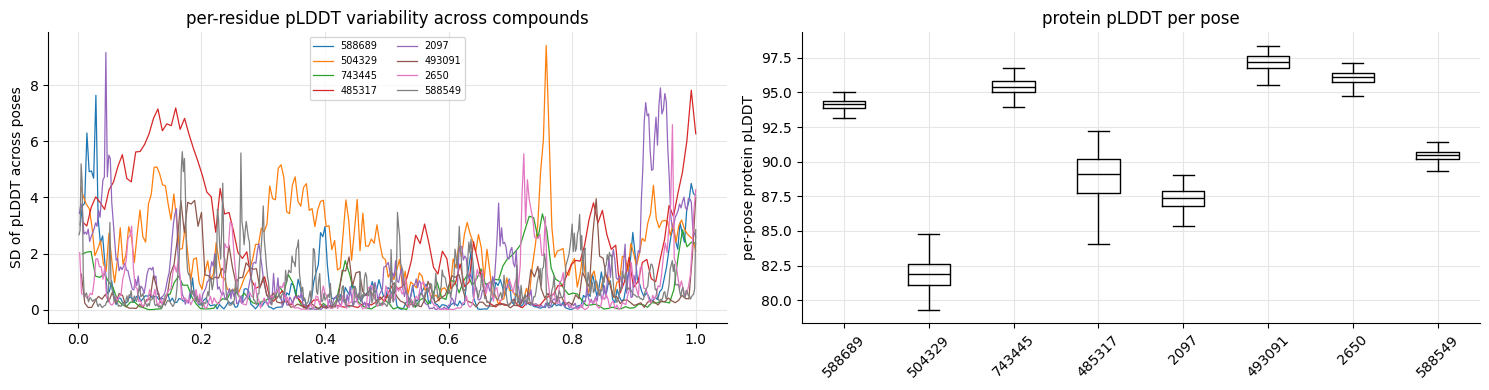

,SD of per-pose protein pLDDT,median per-residue SD,max per-residue SD
target,,,
588689,0.40,0.41,7.6
504329,1.26,2.09,9.4
743445,0.59,0.39,3.4
485317,1.68,1.63,7.8
2097,0.74,0.70,9.2
493091,0.64,0.41,4.0
2650,0.51,0.45,6.6
588549,0.47,0.58,5.6


In [8]:
if READY:
    rows = []; fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    for t in READY:
        P = S[t]["plddt"] * 100; per_pose = P.mean(1); sd_res = P.std(0)
        rows.append({"target": SHORT[t], "SD of per-pose protein pLDDT": round(per_pose.std(), 2), "median per-residue SD": round(float(np.median(sd_res)), 2), "max per-residue SD": round(float(sd_res.max()), 1)})
        axes[0].plot(np.arange(1, P.shape[1] + 1) / P.shape[1], sd_res, lw=0.9, label=SHORT[t])
    axes[0].set_xlabel("relative position in sequence"); axes[0].set_ylabel("SD of pLDDT across poses"); axes[0].set_title("per-residue pLDDT variability across compounds"); axes[0].legend(fontsize=7, ncol=2)
    axes[1].boxplot([S[t]["plddt"].mean(1) * 100 for t in READY], labels=[SHORT[t] for t in READY], showfliers=False, medianprops=dict(color="black")); axes[1].set_ylabel("per-pose protein pLDDT"); axes[1].set_title("protein pLDDT per pose")
    axes[1].tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show(); display(pd.DataFrame(rows).set_index("target"))

## 7. The structures coloured by pLDDT (interactive 3D)
Live 3D views (py3Dmol; needs internet to load the 3Dmol script) of the reference structure coloured by the mean pLDDT of that residue, in the AlphaFold palette: dark blue above 90, light blue 70-90, yellow 50-70, orange below 50. The grey sticks are the ligand of the reference prediction. Ray-traced PyMOL renders of the same colouring are written to `notebooks/figures/<target>_pymol_plddt.png` and `_plddt_side.png` when the render script has been run (`pipeline_local/render_plddt_pymol.py`); they are not embedded here.

In [9]:
import py3Dmol
FIGDIR = ROOT / "notebooks/figures"; FIGDIR.mkdir(exist_ok=True)
for t in READY:
    for v in ("plddt", "plddt_side"):
        p = ROOT / "results/analysis" / t / "render" / f"{v}.png"
        if p.exists(): shutil.copy(p, FIGDIR / f"{t}_pymol_{v}.png")
    pdb = ROOT / "results/analysis" / t / "plddt_colored.pdb"
    if not pdb.exists(): continue
    v = py3Dmol.view(width=800, height=600); v.addModel(pdb.read_text(), "pdb")
    cs = {"prop": "b", "gradient": "linear", "colors": ["#ff7d45", "#ff7d45", "#ffdb13", "#65cbf3", "#0053d6"], "min": 40, "max": 95}
    v.setStyle({"chain": "A"}, {"cartoon": {"colorscheme": cs}}); v.addStyle({"resn": "LIG"}, {"stick": {"colorscheme": "grayCarbon", "radius": 0.25}})
    v.zoomTo(); v.setBackgroundColor("white"); print(f"{SHORT[t]}  mean pLDDT {MEAN[t].mean():.1f}"); v.show()

588689  mean pLDDT 94.1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

504329  mean pLDDT 81.9


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

743445  mean pLDDT 95.4


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

2650  mean pLDDT 96.0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

588549  mean pLDDT 90.4


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 8. Conclusions (every number is computed above)

In [10]:
if not READY: print("no targets with folded poses yet")
else:
    low = T1[T1["% residues < 50"] > 5].index.tolist(); ok = T1[T1["% residues < 50"] <= 1].index.tolist()
    print(f"Targets analysed: {len(READY)} of 8 ({', '.join(SHORT[t] for t in READY)}).")
    print(f"Mean per-residue pLDDT ranges from {T1['mean pLDDT'].min()} ({T1['mean pLDDT'].idxmin()}) to {T1['mean pLDDT'].max()} ({T1['mean pLDDT'].idxmax()}); "
          f"{(T1['% >= 90'] >= 50).sum()} of {len(T1)} targets have at least half of their residues at pLDDT 90 or above.")
    print(f"Targets with more than 5% of residues below pLDDT 50: {low if low else 'none'}; targets with at most 1%: {ok}.")
    if len(T4) and "of which in first/last 10%" in T4:
        tot = int(T4["residues < 50"].sum()); term = int(T4["of which in first/last 10%"].sum())
        print(f"Of {tot} residues below pLDDT 50 across these targets, {term} ({100 * term / max(tot, 1):.0f}%) lie in the first or last 10% of the sequence, i.e. at the termini.")
    print(f"Secondary-structure content of the reference structures: helix {T1['helix %'].min():.0f}-{T1['helix %'].max():.0f}%, sheet {T1['sheet %'].min():.0f}-{T1['sheet %'].max():.0f}% across these targets (the rest is loop), "
          f"and the share of residues below pLDDT 70 is {T1['% < 70'].min():.1f}-{T1['% < 70'].max():.1f}%. Taken together, the structures are folded and mostly confident, not generally disordered, and low-confidence residues are a minority (see section 4 for where). "
          "This is a statement about Boltz-2's confidence in its own prediction; it is not an experimental measure of order.")
    print("Caveats: the pLDDT profile is a sample of about 400 poses per target (fewer for targets still being folded), secondary structure is from one reference prediction per target, "
          "and 504329 and 588549 have no experimental structure in the dataset (predicted sequences), so their pLDDT is the only quality indicator.")

Targets analysed: 8 of 8 (588689, 504329, 743445, 485317, 2097, 493091, 2650, 588549).
Mean per-residue pLDDT ranges from 81.9000015258789 (504329) to 97.0999984741211 (493091); 7 of 8 targets have at least half of their residues at pLDDT 90 or above.
Targets with more than 5% of residues below pLDDT 50: ['504329', '2097']; targets with at most 1%: ['588689', '743445', '485317', '493091', '2650', '588549'].
Of 67 residues below pLDDT 50 across these targets, 58 (87%) lie in the first or last 10% of the sequence, i.e. at the termini.
Secondary-structure content of the reference structures: helix 33-65%, sheet 0-26% across these targets (the rest is loop), and the share of residues below pLDDT 70 is 0.0-19.2%. Taken together, the structures are folded and mostly confident, not generally disordered, and low-confidence residues are a minority (see section 4 for where). This is a statement about Boltz-2's confidence in its own prediction; it is not an experimental measure of order.
Caveats: